# Simplifying notebook 1.2.
This notebook contains the information from 1.2.1, as well as some deeper analysis of the dependence between different parameters. 
Strategy used: 
- Define lotss and WISE parsing functions.
- Create table and save to computer as fits (save time later)

## Imports, Data Retrieval and Filtering

In [1]:
from astroquery.vizier import Vizier
from astropy.table import join
from astropy.table import Table
import os
import warnings
from astropy.utils.metadata import MergeConflictWarning
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt

In [102]:
# RETRIEVE DATA
def lotss_func(lotss_columns_parse, row_lim):
    lotss_filename = "J/A+A/678/A151"
    viz_lotss = Vizier(columns=lotss_columns_parse, row_limit=row_lim)
    viz_lotss.column_filters = {
        "PlateSDSS": ">0",
        "FiberSDSS": ">0",
        "MJDSDSS": ">0"
    } # non-empty plates, etc.
    lotss_data = viz_lotss.get_catalogs(lotss_filename) 
    return lotss_data[0]

def WISE_func(WISE_columns_parse, row_lim):
    viz_WISE = Vizier(columns=WISE_columns_parse, row_limit=row_lim)
    viz_WISE.column_filters = {
        "Plate": ">0",
        "Fiber": ">0",
        "MJD": ">0"
    } # non-empty plates, etc. 
    WISE_filename = "J/ApJ/859/11"
    WISE_data = viz_WISE.get_catalogs(WISE_filename) 

    # preparing for merge later
    WISE_data[1].rename_column('Plate', 'PlateSDSS')
    WISE_data[1].rename_column('MJD', 'MJDSDSS')
    WISE_data[1].rename_column('Fiber', 'FiberSDSS')
    
    return WISE_data[1]


def make_table(lotss_columns_parse, WISE_columns_parse, row_lim, timeout_viz):
    
    vizier_custom = Vizier(row_limit=-1, timeout=timeout_viz)

    LOTSS = lotss_func(lotss_columns_parse, row_lim)
    WISE = WISE_func(WISE_columns_parse, row_lim)

    warnings.filterwarnings('ignore', category=MergeConflictWarning)
    matched_table = join(LOTSS, WISE, keys=['PlateSDSS', 'MJDSDSS', 'FiberSDSS'], join_type='inner')
    
    print(f"Total sources in LoTSS: {len(LOTSS)}")
    print(f"Total sources in GSWLC-2: {len(WISE)}")
    print(f"Successfully matched sources: {len(matched_table)}")
    
    matched_table.write('matched_sources.fits', format='fits', overwrite=True)
    return matched_table


def load_fits_table(file_path='matched_sources.fits'): # function to retrieve written fits file. 
    # 1. Load the table from your computer
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Couldn't find {file_path}. Did you save it yet?")
    matched_table = Table.read(file_path)
    print(f"Successfully loaded {len(matched_table)} sources from disk.")

    return matched_table

In [103]:
# FILTER AND CRETAE NEW COLUMNS

def filter_nan_empty(matched_table): 
    is_valid = ~matched_table['logSFR'].mask & ~matched_table['logMass'].mask
    is_not_nan = ~np.isnan(matched_table['logSFR']) & ~np.isnan(matched_table['logMass'])
    clean_table = matched_table[is_valid & is_not_nan]
    
    print(f"Rows remaining after null-filtering: {len(clean_table)}")
    return clean_table

def flux_to_luminosity(clean_table):
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = clean_table['zphot'].filled(np.nan) 
    dist_m = cosmo.luminosity_distance(z).to(u.m).value # before we had cm**2, but change to m to cancel units
    
    alpha = -0.7
    k_corr = (1 + z)**(alpha - 1)
    flux_w_m2_hz = clean_table['Ftot'] * 1e-29
    luminosity = 4 * np.pi * (dist_m**2) * flux_w_m2_hz * k_corr
    clean_table['logL144'] = np.log10(luminosity)
    clean_table['logL144'].unit = u.dex(u.W / u.Hz)
    
################################
################################

def filtered_new_cols(clean_table):
    
    filter_nan_empty(clean_table)
    flux_to_luminosity(clean_table)
    # ... (other column adding parameters if desired)

    clean_table.write('clean_table.fits', format='fits', overwrite=True)
    return clean_table

## Plotting Data (w/ morphology) and Usage Examples

In [104]:
# MAKE PLOTS

#function to plot two parameters (in clean_table)
def simple_plot(p1, p2, clean_table): # p1, p2 must be STRINGS!
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(clean_table[p1], clean_table[p2], label = 'Data')

    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    x = clean_table[p1][mask]
    coeff =  np.polyfit(x, clean_table[p2][mask], deg=2)

    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = coeff[0] * x_smooth**2 + coeff[1] * x_smooth + coeff[2]
    ax.plot(x_smooth, y_smooth, label = "bestfit", color = 'r')

    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(p1 + " vs. " + p2)
    plt.legend()
    plt.show()

Above are defined all the necessary functions. Below we include, beside the basic parameters, the 'Morphological model' type, which has the following categories for the source galaxy: 
- PSF = 	stellar
- REX = 	round exponential galaxy
- DEV = 	de Vaucouleur
- EXP = 	exponential
- COMP = 	composite

We expect that the different populations will map out nicely in different colors to show a clear trend. We will first retrieve the data, and then create a new plot function (so that data doesn't have to be created each time again). 

In [16]:
lotss_columns_parse = ['PlateSDSS', 'FiberSDSS', 'MJDSDSS', 'Ftot', 'zphot', 'logMass', 'Type']
WISE_columns_parse = ['Plate', 'Fiber', 'MJD', 'logSFR']


matched = make_table(lotss_columns_parse, WISE_columns_parse, row_lim = 10e5, timeout_viz = 1000)
clean_data = filtered_new_cols(matched)

Total sources in LoTSS: 296921
Total sources in GSWLC-2: 361328
Successfully matched sources: 40476


In [27]:
clean_data

PlateSDSS,FiberSDSS,MJDSDSS,Ftot,zphot,logMass,Type,logSFR,logL144
,,d,mJy,,log(solMass),,log(solMass.yr**-1),mJy
int32,int16,int32,float64,float64,float64,bytes4,float32,float64
349,2,51699,1.2646232366737619746,0.0701356,10.2175130844116211,EXP,0.253,26.1573877578187747872
349,25,51699,1.0102712235588247047,0.166734,10.8064422607421875,DEV,0.663,26.8026171371526125142
349,85,51699,2.4999648721656786421,0.109067,10.6218328475952148,DEV,0.888,26.8333053007957822444
349,181,51699,5.0609848096918064186,0.0395527,--,DEV,0.311,26.2646992736611792907
349,191,51699,3.7008151341755879393,0.0957429,10.3283538818359375,EXP,0.396,26.8917519908556812425
349,200,51699,1.5355438107514209900,0.15159,10.7066545486450195,EXP,0.895,26.9033310980754762909
349,223,51699,2.3007047757587058001,0.166867,11.1003141403198242,DEV,1.228,27.1607168530237395032
349,224,51699,1.3245362073503319511,0.112806,--,EXP,0.504,26.5863533560256328769


Successfully loaded 40476 sources from disk.


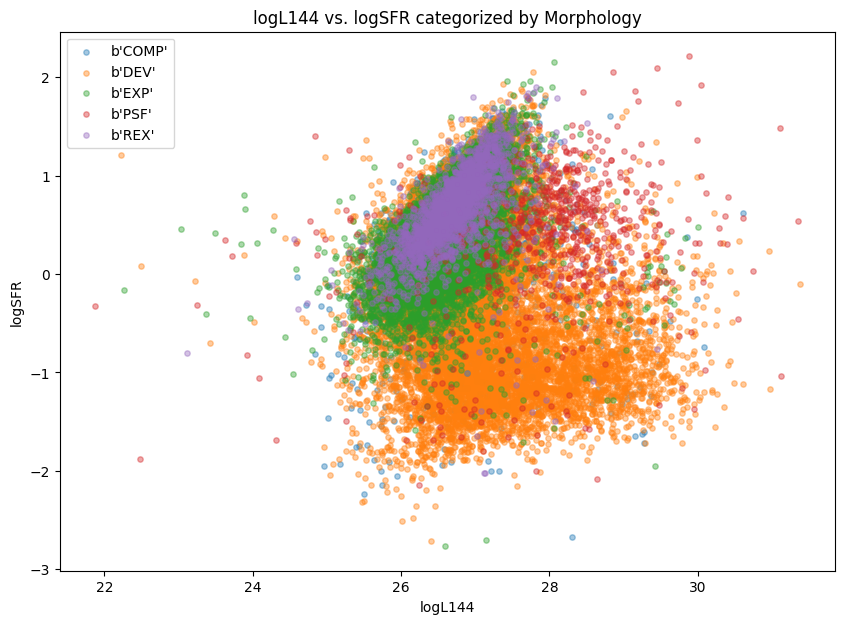

In [14]:
# To create plot we borrow (heavily) from the 'simple plot' function
import numpy as np
import matplotlib.pyplot as plt

def plot_by_morphology(p1, p2, clean_table):
    """
    Plots two parameters with color-coding based on morphological type.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Handle NaN values to ensure polyfit and plotting work correctly
    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    data = clean_table[mask]

    # 2. np.unique returns the sorted unique elements of an array ---> PSF, REX, DEV, EXP, COMP
    morph_types = np.unique(data['Type'])
    for m_type in morph_types:
        type_mask = (data['Type'] == m_type) # filter through each type
        # if we run: mask = (data['Type'] == "DEV"), we get the butterfly figure as before. 
        ax.scatter(
            data[p1][type_mask],  # apply 'type' mask
            data[p2][type_mask], 
            label=m_type, 
            alpha=0.4,   # Transparency for overlapping points
            s=15         # Adjusted point size for clarity
        )

    ''' #OPTIONAL: Calculate and plot the global best-fit line (degree 2) --> should change to fit differnet populations
    x = data[p1]
    y = data[p2]
    coeff = np.polyfit(x, y, deg=2)
    
    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = np.polyval(coeff, x_smooth)
    
    ax.plot(x_smooth, y_smooth, label="Global Best-fit", color='black', linestyle='--', linewidth=2) 
    '''

    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f"{p1} vs. {p2} categorized by Morphology")
    # ax.legend(title="Morphology Type")
    #plt.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.show()presence

clean_data = load_fits_table(file_path='clean_table.fits')
plot_by_morphology("logL144", "logSFR", clean_data)


# Advanced Plot Analysis

## Cutoff lines and Contamination Rate
From above figure, it's very clear (except for DEV population), that SFR scales with luminosity of the galaxy (and hence, SMBH power). 

From paper https://ui.adsabs.harvard.edu/abs/2019A%26A...622A..12H/abstract, Claire commented: *Basically, we observe radio emission from both star forming galaxies and AGN. However, if there's a lot more radio emission than expected, we can guess that that's probably due to the presence of an AGN.*

Hence, we should try to create a cutoff line, and then perform another filtering according to it. 



Successfully loaded 40476 sources from disk.


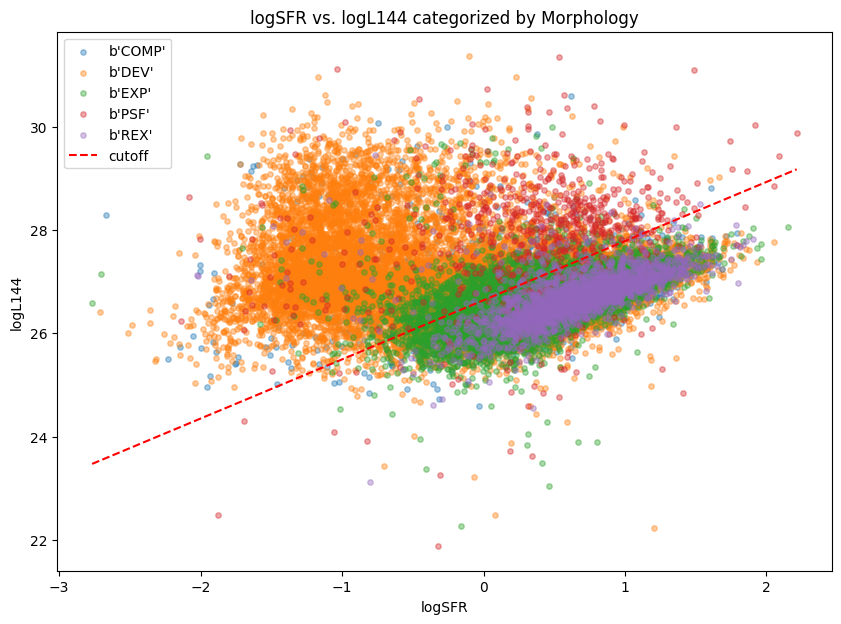

In [56]:
# Plot the cutoff line from visual estimates here: 

def SFG_AGN_cutoff_plot_preliminary_line(p1, p2, clean_table):
    """
    Plots two parameters with color-coding based on morphological type, with a cutoff line between linear scaling and AGN driven. 
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Handle NaN values to ensure polyfit and plotting work correctly
    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    data = clean_table[mask]

    # 2. np.unique returns the sorted unique elements of an array ---> PSF, REX, DEV, EXP, COMP
    morph_types = np.unique(data['Type'])
    for m_type in morph_types:
        type_mask = (data['Type'] == m_type) # filter through each type
        # if we run: mask = (data['Type'] == "DEV"), we get the butterfly figure as before. 
        ax.scatter(
            data[p1][type_mask],  # apply 'type' mask
            data[p2][type_mask], 
            label=m_type, 
            alpha=0.4,   # Transparency for overlapping points
            s=15         # Adjusted point size for clarity
        )

    ''' #OPTIONAL: Calculate and plot the global best-fit line (degree 2) --> should change to fit differnet populations
    x = data[p1]
    y = data[p2]
    coeff = np.polyfit(x, y, deg=2)
    
    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = np.polyval(coeff, x_smooth)
    
    ax.plot(x_smooth, y_smooth, label="Global Best-fit", color='black', linestyle='--', linewidth=2) 
    '''

    '''CUTOFF LINE:  ---> don't include in posterior versions
    Visually, we observe points: (x1, y1) = (0.880, 27.65) ; (x2, y2) = (-0.324, 26.27)
    Hence, we know slope = (y2-y1) / (x2/x1)
    Intercept, where we want y(x) = slope * x + b --> b = y1 - slope * x1
    '''
    x1 = 0.880
    x2 = -0.324
    y1 = 27.65
    y2 = 26.27

    slope = (y2-y1) / (x2-x1)
    intercept = y1 - slope * x1

    x_fit = np.linspace(np.min(data[p1]), np.max(data[p1]), num=50)
    y_fit = x_fit * slope + intercept

    ax.plot(x_fit, y_fit, '--', color = 'r', label = "cutoff")
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f"{p1} vs. {p2} categorized by Morphology")
    # ax.legend(title="Morphology Type")
    #plt.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.show()

clean_data = load_fits_table(file_path='clean_table.fits')
SFG_AGN_cutoff_plot_preliminary_line("logSFR", "logL144",  clean_data)

It is very clear that the purple population (REX) is a Star Forming Galaxy (SFG), and whether (EXP) is also SFG in origin is not so clear. It becomes clear now to distinguish between those galaxy populations and understand exactly what they are describing. 

'Morphological model' type has the following categories for the source galaxy: 
- PSF = 	stellar
- REX = 	round exponential galaxy
- DEV = 	de Vaucouleur
- EXP = 	exponential
- COMP = 	composite
The authors define the classification as "Hubble morphological type (galaxies)".  

As Claire points out: Exponential galaxy fits are consistent with SFG. Converseley, stellar fits (point sources) correspond to quasars. Hence, our line should aim to minimize the no. of EXP & REX Type galaxies, while including as many of the other DEV, COMP and PSF as possible. 

To ensure our selection is not biased, we define a new 'Contamination Rate' (CR), defined as $CR = \frac{Population - no. (Exponential Galaxies)}{Population}$. Then, we should create different lines (by eye), and see which of those minimizes population. 

Before adding any new parameter plots, we should however apply the new cutoff filter to ensure only AGN population. 

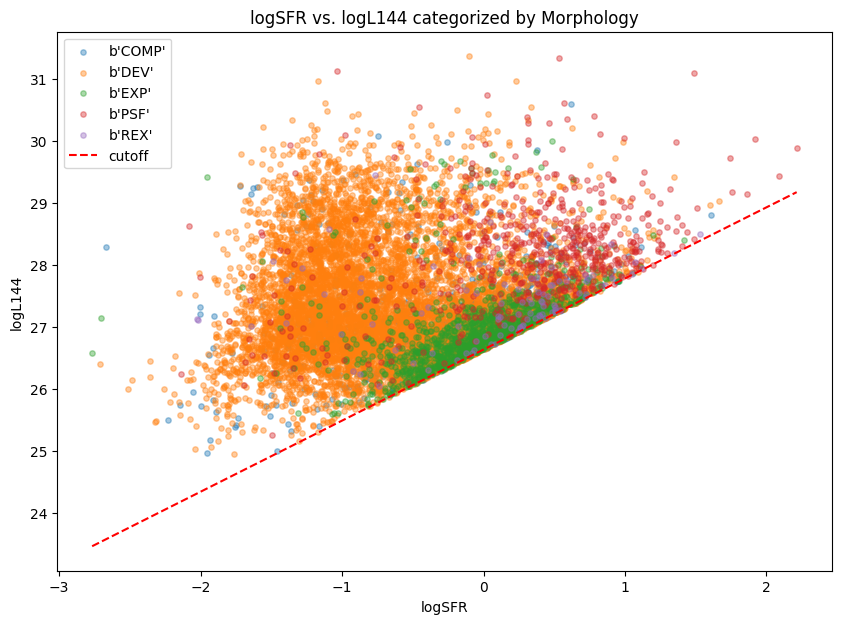

In [57]:
def cutoff_SFG(slope, intercept, data):
    '''
    Definition: Function that will cut off elements under the line that defines the SFG vs. AGN cutoff. 
    To do so, we need to filter out all elements with logL144 > y(logSFR)
    '''
    cutoff_mask = np.where(data['logL144'] > slope * data['logSFR'] + intercept)
    cutoff_table = data[cutoff_mask]
    cutoff_table.write('cutoff_table.fits', format='fits', overwrite=True)
    return cutoff_table

def compute_slope_intercept(x1, x2, y1, y2):
    x1 = 0.880
    x2 = -0.324
    y1 = 27.65
    y2 = 26.27

    slope = (y2-y1) / (x2-x1)
    intercept = y1 - slope * x1

    return slope, intercept

slope, intercept = compute_slope_intercept(x1 = 0.880
    ,x2 = -0.324
    ,y1 = 27.65
    ,y2 = 26.27)


AGN_data = cutoff_SFG(slope, intercept, clean_data)
SFG_AGN_cutoff_plot_preliminary_line("logSFR", "logL144",  AGN_data)

In [58]:
def CR(data):
    '''
    Defn: Function to compute the contamination rate of a galaxy. 
    Population = "all elements that have type category" = len(data['Type']) 
    SFG = "star forming galaxies" = Morphology Type = REX or EXP
    '''
    Population = len(data)
    SFG = np.sum(data['Type'] == "REX") + np.sum(data['Type'] == "EXP") # Sum to get 'True' values in mask

    return SFG / float(Population) # We get the fractional contamination

print(f"Contamination Rate = {CR(AGN_data) * 100 :.2f}%")

Contamination Rate = 11.04%


## Density Computation

With this filter we have now created, we have a preliminary distinction between AGN galaxies and SFG, so we can move on to an analysis of relationship between density and Jet power. 

To get the density, we include a newparameter: 
- r50: (n) Half-light radius of Legacy optical exponential/DeVaucouleurs/composite model

A significant issue is that r50 will only be defined for exponential/DeVaucouleurs/composite models. Hence, we will not be able to analyze density of PSF. 

We can then compute density if we assume a spherical, uniform density. This could be refined later on for better accuracy. 

It is important to note that r50 is not the exact radius of the galaxy, but the radius that contains 50% of the galaxy's luminosity. Yet, it provides a scaling factor sufficient for preliminary density plots. 

In [53]:
lotss_columns_parse = ['PlateSDSS', 'FiberSDSS', 'MJDSDSS', 'Ftot', 'zphot', 'logMass', 'Type', 'r50']
WISE_columns_parse = ['Plate', 'Fiber', 'MJD', 'logSFR']

matched3 = make_table(lotss_columns_parse, WISE_columns_parse, row_lim = 10e5, timeout_viz = 1000)
clean_data3 = filtered_new_cols(matched3)
AGN_table = cutoff_SFG(slope, intercept, clean_data3)

Total sources in LoTSS: 296921
Total sources in GSWLC-2: 361328
Successfully matched sources: 40476
Rows remaining after null-filtering: 24632


In [107]:
def r50_to_radius(data): # Function written completely by GEMINI
    # 1. Setup cosmology from your notebook parameters
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = data['zphot'].filled(np.nan)
    
    # 2. Get the physical scale (kpc per arcsec) as a Quantity
    # cosmo.kpc_proper_per_arcmin returns a Quantity
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec)
    
    # 3. Ensure the angular radius is treated as arcseconds
    # Using u.Quantity ensures we don't double-up units if they already exist[cite: 1]
    r50_angular = u.Quantity(data['r50'].filled(np.nan), u.arcsec)
    
    # 4. Multiply: (arcsec) * (kpc / arcsec) = kpc
    radius_kpc = r50_angular * kpc_per_arcsec
    
    # 5. Convert to cm and return just the numeric value
    return radius_kpc.to(u.cm).value

def radius_to_density(data):
    mass = 10 ** (data['logMass'].filled(np.nan))
    radius = r50_to_radius(data)# data['r50'].filled(np.nan) ---> will get arcsec instead of dist!!

    volume = 4 / float(3) * np.pi * radius**3
    #mask_vol = np.where(volume != 0)

    #mass_filt = mass[mask_vol]
    #vol_filt = volume[mask_vol]

    safe_mask = (volume > 0)

    #     data['rho'] = mass / volume --> this gave division by 0
    data['rho'] = np.nan # ---> initialize cols., and then include values when Vol != 0
    data['rho'].unit = u.solMass / (u.cm**3)
    
    data['rho'][safe_mask] = mass[safe_mask] / volume[safe_mask]


radius_to_density(AGN_table)
AGN_table.write('AGN_table.fits', format='fits', overwrite=True)
AGN_table

PlateSDSS,FiberSDSS,MJDSDSS,Ftot,zphot,logMass,Type,r50,logSFR,logL144,rho
,,d,mJy,,log(solMass),,arcsec,log(solMass.yr**-1),mJy,solMass / cm3
int32,int16,int32,float64,float64,float64,str4,float64,float32,float64,float64
349,237,51699,1.4300945172153345375,0.228401,--,PSF,0,0.248,27.2199500325475156615,nan
349,263,51699,6.6739056016431028695,0.105751,--,COMP,4.348398,0.207,27.2332493011919289927,nan
349,327,51699,1.3116359869395357585,0.132957,--,DEV,12.31476,-0.186,26.7228746553694911370,nan
349,377,51699,38.2339549104478990671,0.334585,--,PSF,0,--,28.9653222589046670521,nan
349,382,51699,3.6115071682928170382,0.267098,--,COMP,6.098126,0.952,27.7535488646927497314,nan
349,391,51699,2.2498137291709712215,0.112086,10.5841741561889648,EXP,3.633582,-0.302,26.8109400591109867662,6.984853593392522e-58
349,392,51699,7.2001103476032346506,0.116718,--,DEV,6.86262,-1.423,27.3508621539992660132,nan
349,465,51699,26.0812228544397619601,0.0922943,--,COMP,11.95194,0.340,27.7082380621191184389,nan


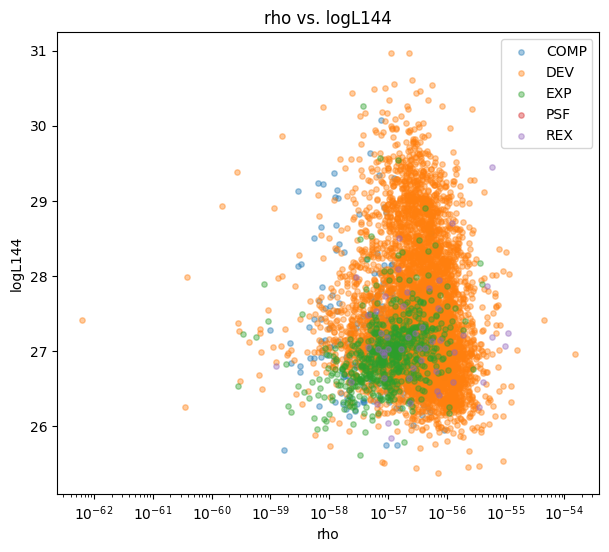

In [100]:
def logax_rho_lum(p1, p2, clean_table):
    fig, ax = plt.subplots(figsize=(7, 6))
    #ax.scatter(clean_table[p1], clean_table[p2], label = 'Data')

    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    x = clean_table[p1][mask]

    ''' don't include bestfit for this plot
    coeff =  np.polyfit(x, clean_table[p2][mask], deg=2)

    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = coeff[0] * x_smooth**2 + coeff[1] * x_smooth + coeff[2]
    ax.plot(x_smooth, y_smooth, label = "bestfit", color = 'r') '''

    #Set LOGARITHMIC scales
    #ax.set_yscale('log') --> logL144 is already in log scaling
    ax.set_xscale('log')

    morph_types = np.unique(clean_table['Type'])
    for m_type in morph_types:
        type_mask = (clean_table['Type'] == m_type) # filter through each type
        # if we run: mask = (data['Type'] == "DEV"), we get the butterfly figure as before. 
        ax.scatter(
            clean_table[p1][type_mask],  # apply 'type' mask
            clean_table[p2][type_mask], 
            label=m_type, 
            alpha=0.4,   # Transparency for overlapping points
            s=15         # Adjusted point size for clarity
        )
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(p1 + " vs. " + p2)
    plt.legend()
    plt.show()

logax_simple_plot('rho', 'logL144', AGN_table)


Here, we are struck by the plot of density vs. Luminoity, where we see that Luminosity does not scale clearly with density. Instead, we find that for a given density the DEV profile (most iteresting for now, since EXP galaxies are SFG) resembles more of a column, showing no linear scaling. Since this is taking into account distinct redshifts, the physics may change. We create a new notebook to test out this hypothesis. 